In [1]:
import graph_tool.collection 
import graph_tool.search 
import graph_tool as gt
import random
import numpy as np
import zstandard
import networkx as nx
import copy
import osmnx as ox

import random
from collections import defaultdict
import matplotlib.pyplot as plt
import os
import subprocess
import ast
import datetime
import time

import gurobipy as gp
from gurobipy import GRB
import igraph as ig

In [2]:
%load_ext autoreload
%autoreload 2

from src import utils as ut


In [35]:
!pwd

/Users/antonioferrara/Desktop/GitHub/Maxmin-Fair-Paths/kspwlo-master


In [36]:
%%time
def load_graph_from_file(filename):
    graph = gt.Graph(directed=True)
    weight_prop = graph.new_edge_property("double")

    # Dictionary to store mapping from node IDs to graph vertex objects
    node_mapping = {}

    with open(filename, 'r') as file:
        for line in file:
            parts = line.strip().split()

            if parts[0] == 'p':
                # Parse the number of nodes and arcs
                num_nodes = int(parts[2])
                num_arcs = int(parts[3])
            elif parts[0] == 'a':
                # Parse the arc information
                source = int(parts[1]) - 1  # Subtract 1 to make it zero-indexed
                target = int(parts[2]) - 1
                weight = np.double(parts[3])

                # Add vertices and edge to the graph
                if source not in node_mapping:
                    node_mapping[source] = graph.add_vertex()
                if target not in node_mapping:
                    node_mapping[target] = graph.add_vertex()

                edge = graph.add_edge(node_mapping[source], node_mapping[target])
                weight_prop[edge] = weight
    
    graph.edge_properties["weight"] = weight_prop
    return graph

# Load the graph from file
filename = '../FairShortPath/data/USA-road-d.FLA.gr'
g_gt = load_graph_from_file(filename)

print("Number of nodes:", g_gt.num_vertices())
print("Number of edges:", g_gt.num_edges())


Number of nodes: 1070376
Number of edges: 2712798
CPU times: user 26.3 s, sys: 1.15 s, total: 27.5 s
Wall time: 27.9 s


In [37]:
place = 'FLA'

In [38]:
def from_gt_to_nx(g, wgt = "weight"):
    g_nx = nx.DiGraph()
    
    for v in g.vertices():
        g_nx.add_node(int(v))
    
    for e in g.edges():
        source = int(e.source())
        target = int(e.target())
        weight = g.ep[wgt][e]  
        g_nx.add_edge(source, target, length=weight)
        #g_nx.add_edge(target, source, length=weight) #if undirected graph ------------
    return(g_nx)

In [39]:
%%time
g = from_gt_to_nx(g_gt, wgt = "weight") 

CPU times: user 21.9 s, sys: 363 ms, total: 22.3 s
Wall time: 22.4 s


In [9]:
seed = 44

In [40]:
def sample_Q1(g, target_count=1, min_length=0, max_length=10000000000, seed=seed):
    random.seed(seed)
    
    nodes = list(g.nodes())
    sampled_pairs = []
    
    while len(sampled_pairs) < target_count:
        u = random.choice(nodes)
        v = random.choice(nodes)
        
        # Skip if u and v are the same
        if u == v:
            continue
        
        # Check shortest path length
        try:
            path_length = nx.shortest_path_length(g, source=u, target=v, weight='length')
            if min_length <= path_length <= max_length:
                sampled_pairs.append((u, v))
        except nx.NetworkXNoPath:
            # Skip if there is no path between u and v
            continue
    
    return sampled_pairs
Q1 = sample_Q1(g)

In [41]:
def transform_to_pairs(data):
    # Group every two tuples and convert to the requested format
    result = [[a, b] for a, b in data]
    return result
def split_components(pairs):
    first_components = [pair[0] for pair in pairs]
    second_components = [pair[1] for pair in pairs]
    return [first_components, second_components]

Q1 = transform_to_pairs(Q1)
Q1 = split_components(Q1)
Q1

[[856761], [244644]]

In [42]:
orig_node,dest_node = Q1
orig_node = orig_node[0]
dest_node = dest_node[0]
wgt = 'length'

In [43]:
orig_node

856761

In [44]:
folder_path = "/Users/antonioferrara/Desktop/GitHub/Maxmin-Fair-Paths/kspwlo-master/"
os.chdir(folder_path)
node_map = ut.save_graph_to_gr(g, 'tmp.gr', source=orig_node, target=dest_node,weight = wgt)
EKSP_node_map = ut.save_graph_to_gr_EKSP(g, 'tmp_EKSP.gr', source=orig_node, target=dest_node,weight = wgt)


In [45]:
dag = ut.get_dag(g, orig_node, dest_node, weight=wgt)
K, alpha, model, result = ut.iterative_solver(dag, orig_node, dest_node) #LP solver, alpha are the satisf. probs
final = ut.compute_probabilities_and_expectations(dag, result, dest_node) 
dag = final['dag']
nx.set_node_attributes(dag, alpha, 'node_flow')

In [46]:
%%time

'''init_time = time.time()
yen_k_shortest_10 = ut.yen_k_paths(g, orig_node, dest_node, weight=wgt, k=5)
ut.add_nodes_satisfaction(yen_k_shortest_10, dag, 'yen')
print(time.time()-init_time)
'''
random_FP_paths = ut.sample_k_random_FP(dag, orig_node, dest_node,  100)
ut.add_nodes_satisfaction(random_FP_paths, dag, 'Random FP')
print(time.time()-init_time)

'''
temp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 5, 0.8, node_map[orig_node], node_map[dest_node], "opplus"), node_map)
ut.add_nodes_satisfaction(temp, dag, 'OP+ 0.8 10')
print(time.time()-init_time)
'''
temp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 10, 0.8, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)
ut.add_nodes_satisfaction(temp, dag, 'ESX-C 0.8 10')
print(time.time()-init_time)

  
with open('tmpQ.txt', 'w') as file:
    file.write(f"{EKSP_node_map[orig_node]} {EKSP_node_map[dest_node]}\n")
    
#temp = EKSP_paths_05_10 = ut.inverse_mapping(ut.execute_EKSP("tmp_EKSP.gr", 10, 0.9), node_map)#it is with node_map results shifted by 1
#ut.add_nodes_satisfaction(temp, dag, 'DKSP')
   

'''
temp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 10, 0.8, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)
ut.add_nodes_satisfaction(temp, dag, 'ESX-C 0.8 10')
print(time.time()-init_time)

temp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 100, 0.5, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)
ut.add_nodes_satisfaction(temp, dag, 'ESX-C 0.5 100')
print(time.time()-init_time)

temp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 100, 0.8, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)
ut.add_nodes_satisfaction(temp, dag, 'ESX-C 0.8 100')
print(time.time()-init_time)

#temp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 10, 0.5, node_map[orig_node], node_map[dest_node], "opplus"), node_map)
#ut.add_nodes_satisfaction(temp, dag, 'OP+ 0.5 10')
'''


2628.2469108104706
2631.389650821686
CPU times: user 194 ms, sys: 38.4 ms, total: 232 ms
Wall time: 3.28 s


'\ntemp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 10, 0.8, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)\nut.add_nodes_satisfaction(temp, dag, \'ESX-C 0.8 10\')\nprint(time.time()-init_time)\n\ntemp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 100, 0.5, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)\nut.add_nodes_satisfaction(temp, dag, \'ESX-C 0.5 100\')\nprint(time.time()-init_time)\n\ntemp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 100, 0.8, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)\nut.add_nodes_satisfaction(temp, dag, \'ESX-C 0.8 100\')\nprint(time.time()-init_time)\n\n#temp = ut.inverse_mapping(ut.execute_bash_command("tmp.gr", 10, 0.5, node_map[orig_node], node_map[dest_node], "opplus"), node_map)\n#ut.add_nodes_satisfaction(temp, dag, \'OP+ 0.5 10\')\n'

In [47]:
#sim_alpha

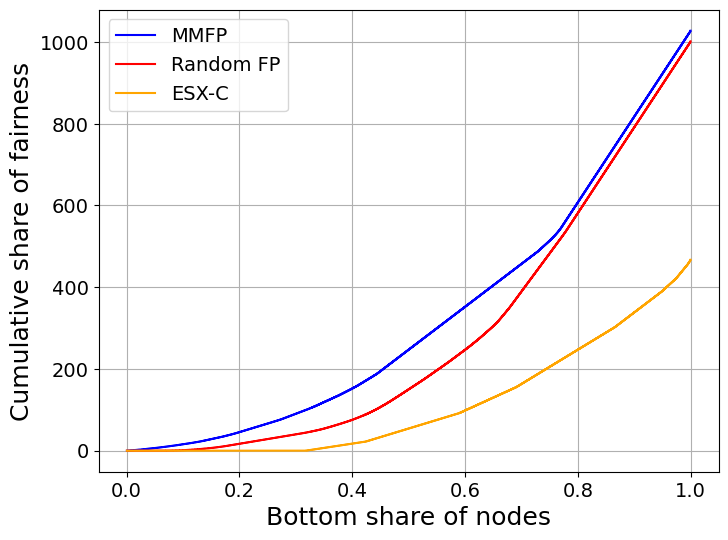

In [50]:
def plot_lorenz_curve(G, attributes=['node_flow'], legend_labels=None):
    """
    Compute and plot the Lorenz curve for the given attributes on the nodes of graph G.
    
    Parameters:
    G (networkx.DiGraph): Directed graph with node attributes.
    attributes (list): List of node attributes to compute the Lorenz curve for. Default is ['node_flow'].
    legend_labels (list or None): List of legend labels corresponding to each attribute. If None, labels are generated automatically.
    
    Returns:
    None: The function plots the Lorenz curves.
    """
    plt.figure(figsize=(8, 6))
    
    if legend_labels is None:
        legend_labels = [f'Lorenz Curve for {attr}' for attr in attributes]
    elif len(legend_labels) != len(attributes):
        raise ValueError("Number of legend labels must match the number of attributes.")
    
    # Create a new graph with nodes that have at least one non-zero attribute
    filtered_nodes = [
        (node, data) for node, data in dag.nodes(data=True)
        if any(data.get(attr, 0) != 0 for attr in attributes)
    ]
    filtered_graph = nx.DiGraph()
    filtered_graph.add_nodes_from(filtered_nodes)
    n = len(filtered_nodes)
    #gini_index = ut.compute_gini_index(np.array(sim_alpha)/sim_alpha[-1])
    #plt.plot(np.arange(1, n + 1) / n, np.array(sim_alpha), drawstyle='steps-post', label='Pointwise Best',color = 'black')

    
    for attribute, label in zip(attributes, legend_labels):
        # Extract the flow values from the nodes in the filtered graph
        flow_values = np.array([data[attribute] for node, data in filtered_graph.nodes(data=True)])
        
        if len(flow_values) == 0:
            raise ValueError(f"No non-zero values found for attribute '{attribute}'")
        
        # Step 1: Sort the flow values in ascending order
        sorted_flow_values = np.sort(flow_values)
        
        # Step 2: Compute the cumulative sum of the sorted flow values
        cumulative_sum = np.cumsum(sorted_flow_values)
        
        # Step 3: Normalize the cumulative sum
        #total_sum = cumulative_sum[-1]
        lorenz_curve = cumulative_sum# / total_sum
        
        # Compute the Gini index
        gini_index = ut.compute_gini_index(lorenz_curve/cumulative_sum[-1])
        
        # Add Gini index to the label
        #label_with_gini = f'{label} (Gini: {gini_index:.3f})'

        #label_with_gini = f'{label} (Gini: {gini_index:.3f})'
        
        # Plot the Lorenz curve
        n = len(lorenz_curve)
        if label == 'MMFP':
            plt.plot(np.arange(1, n + 1) / n, lorenz_curve, drawstyle='steps-post', label=label, color = 'blue')
            
        elif label == 'Random FP':
                
            plt.plot(np.arange(1, n + 1) / n, lorenz_curve, drawstyle='steps-post', label=label, color = 'red')

        elif label == 'Yen':
                
            plt.plot(np.arange(1, n + 1) / n, lorenz_curve, drawstyle='steps-post', label=label, color = 'green')
        elif label == 'OP+':
                
            plt.plot(np.arange(1, n + 1) / n, lorenz_curve, drawstyle='steps-post', label=label, color = 'magenta')

        elif label == 'DKSP':
                
            plt.plot(np.arange(1, n + 1) / n, lorenz_curve, drawstyle='steps-post', label=label, color = 'cyan')
        elif label == 'ESX-C':
                
            plt.plot(np.arange(1, n + 1) / n, lorenz_curve, drawstyle='steps-post', label=label, color = 'orange')

        else:
            plt.plot(np.arange(1, n + 1) / n, lorenz_curve, drawstyle='steps-post', label=label)
    
    #plt.plot([0, 1], [0, 1], color='k', linestyle='--', label='Equality Line')
    

    
    plt.xlabel('Bottom share of nodes', fontsize=18)  # Larger x-axis label font size
    plt.ylabel('Cumulative share of fairness', fontsize=18)  # Larger y-axis label font size
    plt.legend(fontsize=14)  # Larger legend font size
    plt.grid(True)
    
    # Adjust xticks and yticks font size
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    
    current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    directory = '../FairShortPath/plots_lorenz'
    filename = f'{directory}/{place}_{str(seed)}methods.pdf'
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

    
    

attributes =  ['node_flow', 'Random FP','ESX-C 0.8 10']
legend_labels =  ['MMFP',   'Random FP'  ,    'ESX-C' ]
plot_lorenz_curve(dag, attributes=attributes, legend_labels=legend_labels)

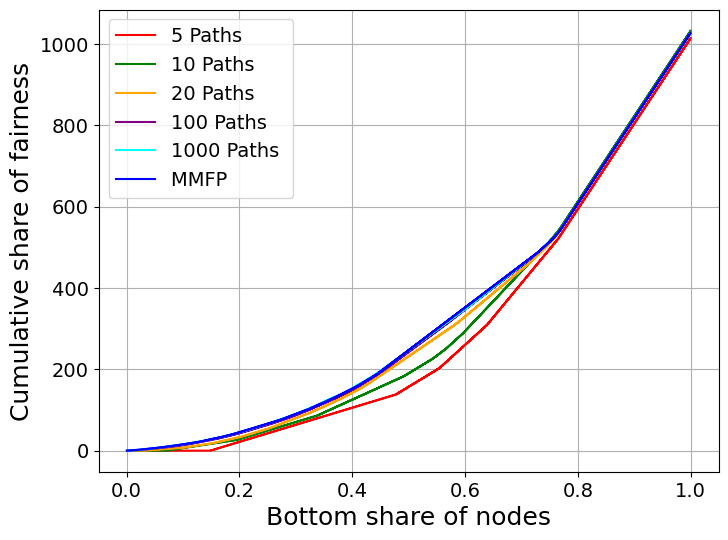

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import datetime

ks = [5, 10, 20, 100, 1000]


for k in ks:
    paths = ut.sample_k_FP(dag, orig_node, dest_node,  k)
    ut.add_nodes_satisfaction(paths, dag, str(k))

def plot_lorenz_curve(G, attributes=['node_flow'], legend_labels=None, colors=None):
    """
    Compute and plot the Lorenz curve for the given attributes on the nodes of graph G.
    
    Parameters:
    G (networkx.DiGraph): Directed graph with node attributes.
    attributes (list): List of node attributes to compute the Lorenz curve for. Default is ['node_flow'].
    legend_labels (list or None): List of legend labels corresponding to each attribute. If None, labels are generated automatically.
    colors (list or None): List of colors for each attribute curve. If None, default colors will be used.
    
    Returns:
    None: The function plots the Lorenz curves.
    """
    plt.figure(figsize=(8, 6))
    
    if legend_labels is None:
        legend_labels = [f'Lorenz Curve for {attr}' for attr in attributes]
    elif len(legend_labels) != len(attributes):
        raise ValueError("Number of legend labels must match the number of attributes.")
        
    if colors is None:
        colors = plt.cm.tab10(range(len(attributes)))  # Use a default colormap if no colors are specified
    elif len(colors) != len(attributes):
        raise ValueError("Number of colors must match the number of attributes.")
    
    # Create a new graph with nodes that have at least one non-zero attribute
    filtered_nodes = [
        (node, data) for node, data in dag.nodes(data=True)
        if any(data.get(attr, 0) != 0 for attr in attributes)
    ]
    filtered_graph = nx.DiGraph()
    filtered_graph.add_nodes_from(filtered_nodes)
    
    for attribute, label, color in zip(attributes, legend_labels, colors):
        # Extract the flow values from the nodes in the filtered graph
        flow_values = np.array([data[attribute] for node, data in filtered_graph.nodes(data=True)])
        
        if len(flow_values) == 0:
            raise ValueError(f"No non-zero values found for attribute '{attribute}'")
        
        # Step 1: Sort the flow values in ascending order
        sorted_flow_values = np.sort(flow_values)
        
        # Step 2: Compute the cumulative sum of the sorted flow values
        cumulative_sum = np.cumsum(sorted_flow_values)
        
        # Step 3: Normalize the cumulative sum
        total_sum = cumulative_sum[-1]
        lorenz_curve = cumulative_sum / total_sum
        
        # Compute the Gini index
        gini_index = ut.compute_gini_index(lorenz_curve)
        
        # Add Gini index to the label
        if label != 'MMFP':
            label_with_gini = f'{label} Paths '
        else:
            label_with_gini = f'{label} '
        
        # Plot the Lorenz curve
        n = len(lorenz_curve)
        plt.plot(np.arange(1, n + 1) / n, cumulative_sum, drawstyle='steps-post', label=label_with_gini, color=color)

    # Plot the equality line
    #plt.plot([0, 1], [0, 1], color='k', linestyle='--', label='Equality Line')
    
    plt.xlabel('Bottom share of nodes', fontsize=18)  # Larger x-axis label font size
    plt.ylabel('Cumulative share of fairness', fontsize=18)  # Larger y-axis label font size
    plt.legend(fontsize=14)  # Larger legend font size
    plt.grid(True)
    
    # Adjust xticks and yticks font size
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    
    current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    directory = '../FairShortPath/plots_lorenz'
    filename = f'{directory}/{place}_{str(seed)}convergence.pdf'
    plt.savefig(filename, bbox_inches='tight')
    
    plt.show()

# Example usage
kstring = [str(k) for k in ks]  
attributes = kstring + ['node_flow']
legend_labels = kstring + ['MMFP']

# Define custom colors for each Lorenz curve
custom_colors = ['red', 'green', 'orange', 'purple', 'cyan', 'blue']  # Adjust colors as needed

plot_lorenz_curve(dag, attributes=attributes, legend_labels=legend_labels, colors=custom_colors)
